In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('report_Lisbon_Coimbra_FDR1.pg_matrix.csv')

In [2]:
 df.shape

(502, 144)

In [3]:
df

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,C:\Manadas\share_PC_Manadas\DanielaAraujo\S01_LIS020_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S02_LIS054_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S03_LIS044_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\S04_LIS053_10uLof30uL_SWATH.wiff.dia,...,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S51_100111_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S52_104726_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S53_105438_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S54_105080_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S55_109901_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S56_109089_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S57_103176_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S58_102357_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S59_107362_10uLof30uL_SWATH.wiff.dia,C:\Manadas\share_PC_Manadas\DanielaAraujo\Coimbra\S60_109522_10uLof30uL_SWATH.wiff.dia
0,A0A075B6H7,KV37_HUMAN,IGKV3-7,Probable non-functional immunoglobulin kappa v...,2,1,969.61400,914.1070,4181.8800,1906.0000,...,796.1010,1518.6300,3103.8900,2960.9100,6094.2500,2543.1300,5165.1900,3539.4800,1400.8100,1649.2100
1,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,9.27816,55.3586,143.9310,NaN,...,21.3081,NaN,NaN,18.4292,72.0558,46.6377,64.4440,47.2177,12.7926,75.8472
2,A0A075B6J9,LV218_HUMAN,IGLV2-18,Immunoglobulin lambda variable 2-18,2,1,21.44890,17.1950,27.1846,55.2968,...,NaN,NaN,NaN,NaN,68.5982,37.8363,NaN,NaN,NaN,NaN
3,A0A075B6K4;P01717,LV310_HUMAN;LV325_HUMAN,IGLV3-10;IGLV3-25,Immunoglobulin lambda variable 3-10,1,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2132,NaN,NaN
4,A0A075B6K5,LV39_HUMAN,IGLV3-9,Immunoglobulin lambda variable 3-9,2,1,109.66000,69.7024,263.1580,205.0320,...,23.9555,22.3354,43.3304,44.2350,72.1073,67.3014,37.2292,60.0842,16.0189,35.0615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,Q9Y6R7,FCGBP_HUMAN,FCGBP,IgGFc-binding protein,33,33,178.62300,130.5690,477.2400,243.9730,...,209.6860,143.2610,175.5890,202.2820,227.6950,264.7280,171.9760,205.1030,218.9400,250.7890
498,cRAP-P00760,cRAP-TRY1_BOVIN,NaN,Cationic trypsin,5,5,190788.00000,170855.0000,430905.0000,252990.0000,...,64922.1000,177434.0000,251155.0000,321702.0000,299434.0000,195037.0000,150859.0000,114554.0000,131916.0000,199896.0000
499,cRAP-P00761,cRAP-TRYP_PIG,NaN,Trypsin,2,2,403.65400,332.3180,807.7940,503.1910,...,328.8880,278.1110,162.2850,136.7970,76.8350,247.4770,NaN,40.4086,282.2720,194.1680
500,cRAP-P0AEY0,MALE_ECO57,malE,Maltose-binding periplasmic protein,39,39,133980.00000,137233.0000,322812.0000,196429.0000,...,46812.0000,111678.0000,144365.0000,185307.0000,138375.0000,102014.0000,153716.0000,145426.0000,72533.7000,162551.0000


Refining Column Headers for Enhanced Sample Identification

Adjusting column metadata to improve the readability of patient identifiers (IDs) and ensure consistent data visualization.

In [4]:
import re

def extract_id(col):
    # caso LIS
    m1 = re.search(r"LIS\d+", col)
    if m1:
        return m1.group()
    
    # caso Coimbra numerico
    m2 = re.search(r'_(\d+)_', col)
    if m2:
        return m2.group(1)
    
    return col

df.columns = [extract_id(c) for c in df.columns]

In [5]:
metadata_cols = df.columns[:6]
sample_cols = df.columns[6:]
coimbra_samples = [col for col in sample_cols if not col.startswith("LIS")]
df_coimbra = df[list(metadata_cols) + coimbra_samples]

In [6]:
df_coimbra

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,109094,103208,106086,105634,...,100111,104726,105438,105080,109901,109089,103176,102357,107362,109522
0,A0A075B6H7,KV37_HUMAN,IGKV3-7,Probable non-functional immunoglobulin kappa v...,2,1,1671.8800,1458.5200,2033.6700,3341.5800,...,796.1010,1518.6300,3103.8900,2960.9100,6094.2500,2543.1300,5165.1900,3539.4800,1400.8100,1649.2100
1,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,NaN,63.6820,NaN,186.0430,...,21.3081,NaN,NaN,18.4292,72.0558,46.6377,64.4440,47.2177,12.7926,75.8472
2,A0A075B6J9,LV218_HUMAN,IGLV2-18,Immunoglobulin lambda variable 2-18,2,1,21.2718,NaN,NaN,37.3834,...,NaN,NaN,NaN,NaN,68.5982,37.8363,NaN,NaN,NaN,NaN
3,A0A075B6K4;P01717,LV310_HUMAN;LV325_HUMAN,IGLV3-10;IGLV3-25,Immunoglobulin lambda variable 3-10,1,0,NaN,NaN,21.6734,98.7700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2132,NaN,NaN
4,A0A075B6K5,LV39_HUMAN,IGLV3-9,Immunoglobulin lambda variable 3-9,2,1,42.5550,17.4106,40.0548,104.4740,...,23.9555,22.3354,43.3304,44.2350,72.1073,67.3014,37.2292,60.0842,16.0189,35.0615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,Q9Y6R7,FCGBP_HUMAN,FCGBP,IgGFc-binding protein,33,33,125.1840,135.1890,181.7270,108.7160,...,209.6860,143.2610,175.5890,202.2820,227.6950,264.7280,171.9760,205.1030,218.9400,250.7890
498,cRAP-P00760,cRAP-TRY1_BOVIN,NaN,Cationic trypsin,5,5,91673.3000,98989.6000,116982.0000,106129.0000,...,64922.1000,177434.0000,251155.0000,321702.0000,299434.0000,195037.0000,150859.0000,114554.0000,131916.0000,199896.0000
499,cRAP-P00761,cRAP-TRYP_PIG,NaN,Trypsin,2,2,100.8050,402.9230,138.0460,420.3910,...,328.8880,278.1110,162.2850,136.7970,76.8350,247.4770,NaN,40.4086,282.2720,194.1680
500,cRAP-P0AEY0,MALE_ECO57,malE,Maltose-binding periplasmic protein,39,39,70948.4000,74523.2000,64654.2000,42125.8000,...,46812.0000,111678.0000,144365.0000,185307.0000,138375.0000,102014.0000,153716.0000,145426.0000,72533.7000,162551.0000


In [7]:
len(df_coimbra.columns.unique())

66

In [8]:
print(df_coimbra.columns[df_coimbra.columns.duplicated()].unique())

Index([], dtype='object')


Data Restructuring: Transposition and Feature Selection

The protein expression matrix was transposed to align with standard statistical analysis formats, placing individual patients in rows and protein identifiers in columns. During this process, non-quantitative columns (metadata not representing protein intensities) were removed to ensure the dataset exclusively contains numerical expression values for downstream processing.

In [9]:
df_indexed = df_coimbra.set_index('Protein.Group')

In [10]:
df_numeric = df_indexed.iloc[:, 5:]

In [11]:
df_matrix_T = df_numeric.T

In [12]:
df_matrix_T

Protein.Group,A0A075B6H7,A0A075B6I0,A0A075B6J9,A0A075B6K4;P01717,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6R2,A0A075B6R9;A0A0C4DH68,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A075B6S9;P0DSN7,...,Q9Y4C0,Q9Y5I4,Q9Y5Y7,Q9Y646,Q9Y6N7,Q9Y6R7,cRAP-P00760,cRAP-P00761,cRAP-P0AEY0,cRAP-P42212
109094,1671.880,NaN,21.27180,NaN,42.55500,1041.100,NaN,152.3720,199.2530,NaN,...,175.849,15.81140,9.70757,70.5147,10.88300,125.1840,91673.3,100.8050,70948.4,130933.0
103208,1458.520,63.68200,NaN,NaN,17.41060,949.564,NaN,87.8526,125.2560,NaN,...,167.257,12.72460,8.79752,84.3873,19.33370,135.1890,98989.6,402.9230,74523.2,125647.0
106086,2033.670,NaN,NaN,21.6734,40.05480,1195.270,NaN,293.4530,183.8210,NaN,...,228.481,18.02940,12.47090,95.8454,17.20210,181.7270,116982.0,138.0460,64654.2,110566.0
105634,3341.580,186.04300,37.38340,98.7700,104.47400,2595.790,28.85160,385.6820,415.8910,NaN,...,156.193,18.64960,9.59901,74.8747,22.39010,108.7160,106129.0,420.3910,42125.8,75019.7
106008,1702.060,20.11950,NaN,30.2006,26.06480,1601.270,NaN,177.8050,257.0170,NaN,...,162.381,14.17280,9.47071,75.0833,NaN,202.1580,150851.0,629.5880,61125.7,109242.0
110203,1214.240,8.47566,NaN,NaN,19.60210,605.131,NaN,NaN,158.0480,NaN,...,205.953,13.51130,13.19080,72.1914,13.54650,129.5810,196623.0,702.7250,109802.0,203149.0
108382,2243.970,21.70880,NaN,NaN,50.84660,1245.040,NaN,156.5940,207.6900,NaN,...,161.568,24.19740,10.64850,85.8660,NaN,254.9040,114453.0,91.0212,60644.7,121388.0
104968,1670.690,56.57990,NaN,NaN,42.29030,1088.020,NaN,121.0580,221.1610,NaN,...,171.436,NaN,9.83174,95.0568,NaN,309.8280,133809.0,131.9390,88051.6,144493.0
107018,1287.460,45.30020,NaN,46.9160,51.47630,1224.080,NaN,255.2090,169.4860,NaN,...,182.320,12.19790,NaN,59.0637,14.47800,89.1420,124207.0,116.6400,112070.0,187149.0
109456,719.598,20.24170,NaN,11.5385,7.80332,454.900,9.35698,NaN,97.2967,3.84055,...,197.493,13.07240,7.83692,74.8901,9.17694,80.0901,120992.0,NaN,101384.0,177167.0


Quality Control: Assessment of Missing Values (NaN)

We performed a comprehensive screening of the dataset to quantify missing data (NaN values). The analysis was conducted at two levels: per-protein (column-wise) and per-patient (row-wise). Both absolute counts and percentage distributions were calculated to evaluate data completeness and identify potential outliers or low-quality features

In [13]:
list_prot_nan = df_matrix_T.isna().sum().tolist()

In [14]:
list_examples_nan = df_matrix_T.isna().sum(axis=1).tolist()

In [15]:
df_matrix_T.isna().sum().sum()

6597

In [16]:
perc_prot = []
n_patients = df_matrix_T.shape[0]
for i in list_prot_nan:
    res = (i/n_patients)*100
    perc_prot.append(res)

In [17]:
n_patients

60

In [18]:
perc_examples = []
n_proteins = df_matrix_T.shape[1]
for i in list_examples_nan:
    res_2 = (i/n_proteins)*100
    perc_examples.append(res_2)

In [19]:
n_proteins

502

In [20]:
perc_prot = pd.Series(perc_prot)
perc_prot.describe()

count    502.000000
mean      21.902390
std       30.656034
min        0.000000
25%        0.000000
50%        3.333333
75%       35.000000
max      100.000000
dtype: float64

In [21]:
perc_examples = pd.Series(perc_examples)
perc_examples.describe()

count    60.000000
mean     21.902390
std       5.921876
min      12.948207
25%      17.878486
50%      21.414343
75%      23.804781
max      46.015936
dtype: float64

In [22]:
import matplotlib.pyplot as plt

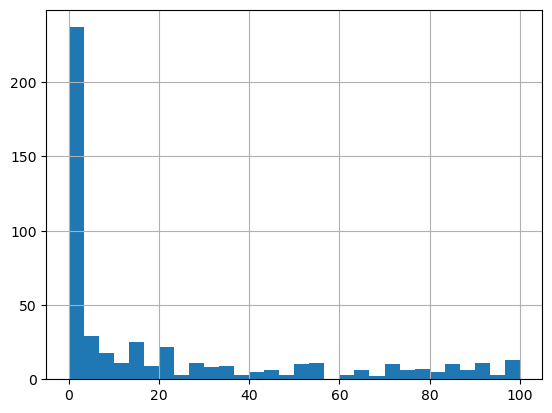

In [23]:
perc_prot.describe()
perc_prot.hist(bins=30)
plt.savefig('distribution_hist_nan_proteins_Coimbra.png')

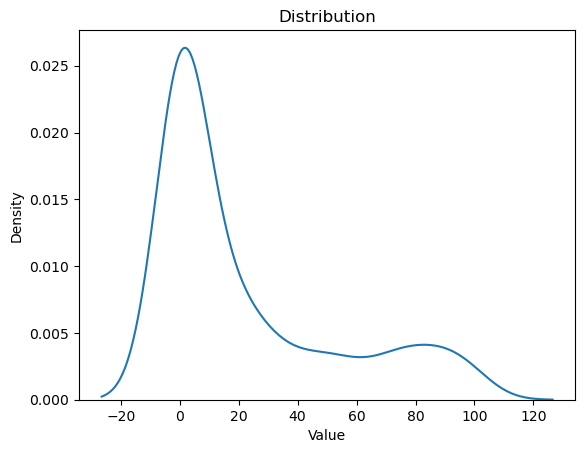

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(perc_prot)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.savefig('distribution_nan_proteins_Coimbra.png')
plt.show()

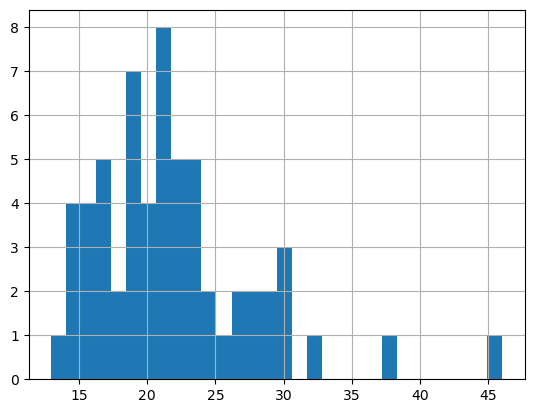

In [25]:
perc_examples.describe()
perc_examples.hist(bins=30)
plt.savefig('distribution_nan_samples_hist_Coimbra.png')

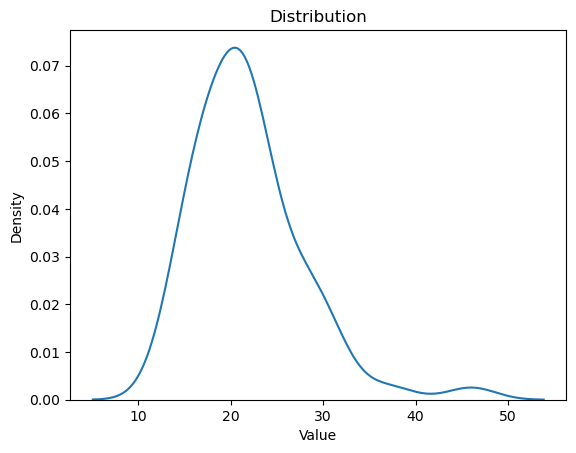

In [26]:
sns.kdeplot(perc_examples)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.savefig('distribution_nan_samples_Coimbra.png')
plt.show()

In [27]:
(perc_prot > 50).sum()

97

In [28]:
(perc_prot > 70).sum()

64

In [29]:
perc_prot.sort_values(ascending=False)

481    100.0
12     100.0
309    100.0
406    100.0
325    100.0
       ...  
202      0.0
201      0.0
197      0.0
196      0.0
501      0.0
Length: 502, dtype: float64

In [30]:
perc_examples.sort_values(ascending=False)

13    46.015936
27    37.250996
48    32.071713
46    30.478088
56    30.478088
58    29.681275
54    29.282869
53    28.685259
38    27.689243
30    27.490040
32    27.091633
42    26.494024
35    26.095618
22    24.302789
52    24.103586
47    23.705179
29    23.705179
43    23.705179
55    23.705179
3     22.908367
33    22.310757
25    22.310757
44    22.111554
23    22.111554
45    22.111554
6     21.713147
7     21.713147
28    21.513944
50    21.513944
36    21.513944
37    21.314741
40    20.916335
10    20.717131
57    20.517928
12    20.318725
19    19.920319
34    19.920319
1     19.521912
20    19.322709
51    19.123506
8     18.924303
21    18.725100
59    18.525896
24    18.525896
41    17.928287
15    17.729084
16    16.932271
5     16.733068
4     16.733068
49    16.533865
18    16.334661
26    16.135458
31    16.135458
14    15.936255
39    15.338645
0     15.139442
17    14.541833
2     14.541833
9     14.342629
11    12.948207
dtype: float64

Exploratory Data Analysis: Distribution and Correlation Profiling

To assess the overall data quality and consistency, we performed an Exploratory Data Analysis (EDA). A boxplot of protein intensities was generated for each sample to evaluate normalization and identify potential batch effects. Additionally, a Pearson correlation heatmap was constructed to visualize global similarities between patient profiles and ensure biological consistency

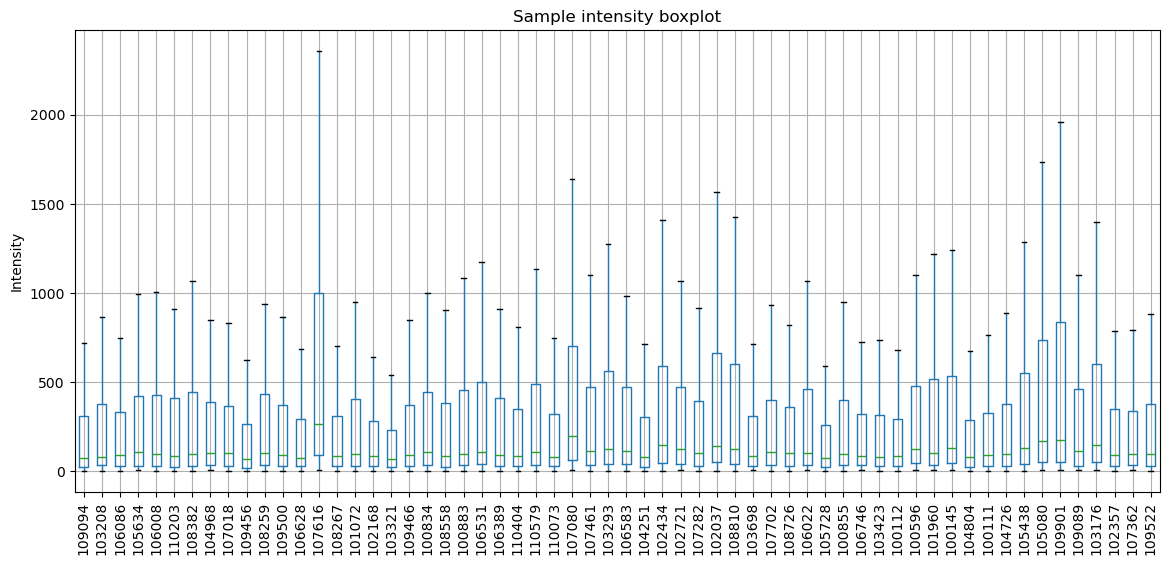

In [31]:
plt.figure(figsize=(14,6))
df_matrix_T.T.boxplot(showfliers=False)
plt.xticks(rotation=90)
plt.ylabel("Intensity")
plt.title("Sample intensity boxplot")
dpi=300
plt.savefig('Sample_intensity_boxplot_Coimbra.png')
plt.show()

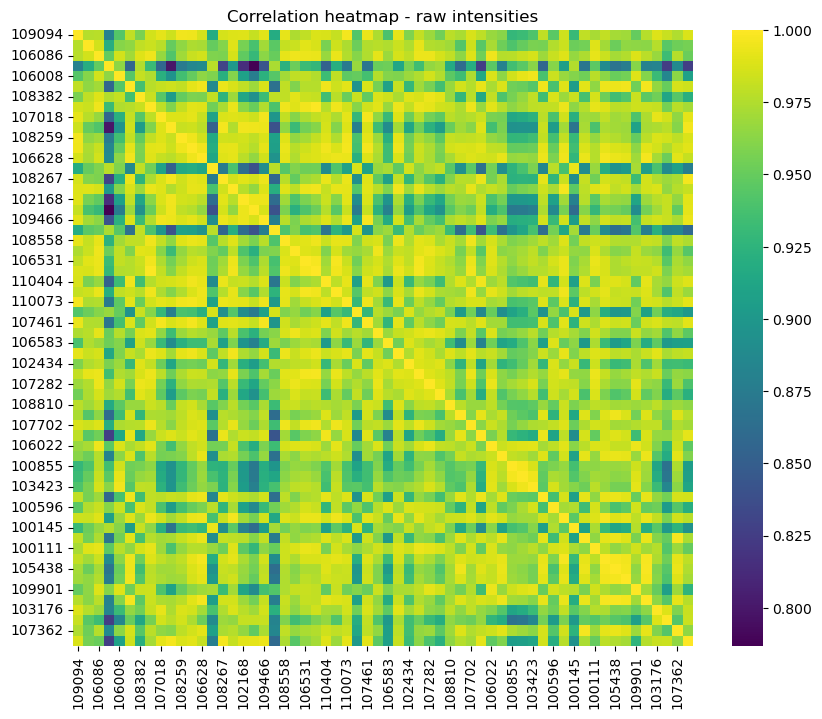

In [32]:
import seaborn as sns

# correlazione tra pazienti
corr_matrix = df_matrix_T.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="viridis")
plt.title("Correlation heatmap - raw intensities")
dpi=300
plt.savefig('Correlation_heatmap.png')
plt.show()

FILTERING

Data Filtering Based on Missing Value Thresholds

To ensure the statistical power of the analysis, a filtering step was implemented based on the percentage of missing values (NaN). Features (proteins) and observations (patients) that exceeded a predefined threshold of missingness were excluded. This process refines the dataset, retaining only the most robust and informative variables for downstream statistical testing.

In [33]:
perc_prot.sort_values(ascending=False)

481    100.0
12     100.0
309    100.0
406    100.0
325    100.0
       ...  
202      0.0
201      0.0
197      0.0
196      0.0
501      0.0
Length: 502, dtype: float64

In [34]:
count = 0

for i in perc_prot.tolist():
    if i == 0:
        count += 1
print(count)

215


In [35]:
df_clean_Nan = df_matrix_T.dropna(axis=1)

In [36]:
df_clean_Nan

Protein.Group,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X8,A0A0B4J1Y9,A0A0B4J2B5,...,Q9P2S2,Q9UBP4,Q9UKI9;P09086;P14859,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7,cRAP-P00760,cRAP-P0AEY0,cRAP-P42212
109094,1671.880,42.55500,1041.100,199.2530,1013.880,40.4669,151.6120,635.496,546.899,1749.830,...,108.3690,2572.73,522.7750,125.9220,175.849,70.5147,125.1840,91673.3,70948.4,130933.0
103208,1458.520,17.41060,949.564,125.2560,1006.140,95.0904,66.8632,507.168,427.962,2446.030,...,105.6060,2614.61,1261.0800,108.4720,167.257,84.3873,135.1890,98989.6,74523.2,125647.0
106086,2033.670,40.05480,1195.270,183.8210,1214.440,71.9299,109.1410,640.271,713.329,2708.360,...,107.0140,3086.48,961.3060,160.3690,228.481,95.8454,181.7270,116982.0,64654.2,110566.0
105634,3341.580,104.47400,2595.790,415.8910,2746.840,176.6480,60.3392,898.984,684.422,5290.490,...,90.5365,3251.29,1443.6400,81.8759,156.193,74.8747,108.7160,106129.0,42125.8,75019.7
106008,1702.060,26.06480,1601.270,257.0170,1382.840,36.7752,294.6000,842.541,619.295,2923.140,...,67.0476,3487.58,1330.1000,133.8390,162.381,75.0833,202.1580,150851.0,61125.7,109242.0
110203,1214.240,19.60210,605.131,158.0480,1112.040,67.6687,436.2690,555.120,384.818,1698.240,...,116.8190,3564.90,712.9700,145.3150,205.953,72.1914,129.5810,196623.0,109802.0,203149.0
108382,2243.970,50.84660,1245.040,207.6900,956.268,87.5769,560.3770,537.280,609.829,2347.940,...,100.8840,2936.42,1054.0100,104.8390,161.568,85.8660,254.9040,114453.0,60644.7,121388.0
104968,1670.690,42.29030,1088.020,221.1610,848.697,76.0238,301.5490,767.240,383.128,2700.050,...,94.1583,2653.00,679.2560,124.3220,171.436,95.0568,309.8280,133809.0,88051.6,144493.0
107018,1287.460,51.47630,1224.080,169.4860,1130.490,87.8945,393.8890,792.661,690.915,3320.010,...,106.5340,2433.14,1318.7600,120.5250,182.320,59.0637,89.1420,124207.0,112070.0,187149.0
109456,719.598,7.80332,454.900,97.2967,623.157,18.7789,19.9611,395.655,221.514,1253.270,...,94.6995,3069.24,530.1000,143.0260,197.493,74.8901,80.0901,120992.0,101384.0,177167.0


In [37]:
df_clean_Nan.isnull().sum().sum()

0

LOG2 TRANFORMATION

Data Transformation and Post-Normalization AssessmentProtein intensities were $\log_2$-transformed to stabilize variance and reduce the skewness of the data distribution. Following the transformation, we re-evaluated the dataset using boxplots and correlation heatmaps. This step ensures that the transformation successfully homogenized the signal across samples and prepared the data for robust statistical comparisons.

In [38]:
data_log2 = np.log2(df_clean_Nan)

In [39]:
data_log2

Protein.Group,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X8,A0A0B4J1Y9,A0A0B4J2B5,...,Q9P2S2,Q9UBP4,Q9UKI9;P09086;P14859,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7,cRAP-P00760,cRAP-P0AEY0,cRAP-P42212
109094,10.707256,5.411257,10.023893,7.638458,9.985671,5.338670,7.244240,9.311739,9.095131,10.772999,...,6.759808,11.329084,9.030046,6.976387,7.458193,6.139852,6.967906,16.484214,16.114483,16.998469
103208,10.510289,4.121894,9.891121,6.968736,9.974615,6.571228,6.063140,8.986320,8.741339,11.256226,...,6.722548,11.352380,10.300444,6.761179,7.385923,6.398954,7.078834,16.594989,16.185402,16.939017
106086,10.989870,5.323903,10.223121,7.522158,10.246075,6.168520,6.770049,9.322539,9.478424,11.403204,...,6.741656,11.591747,9.908852,7.325251,7.835930,6.582637,7.505629,16.835927,15.980456,16.754548
105634,11.706315,6.707000,11.341958,8.700062,11.423557,7.464734,5.915024,9.812152,9.418742,12.369186,...,6.500428,11.666797,10.495495,6.355367,7.287186,6.226406,6.764420,16.695459,15.362416,16.194982
106008,10.733066,4.704031,10.645001,8.005720,10.433419,5.200661,8.202614,9.718603,9.274483,11.513303,...,6.067114,11.768011,10.377319,7.064355,7.343239,6.230420,7.659339,17.202765,15.899491,16.737168
110203,10.245838,4.292936,9.241104,7.304219,10.118993,6.080417,8.769074,9.116656,8.588032,10.729825,...,6.868131,11.799646,9.477698,7.183040,7.686171,6.173755,7.017710,17.585073,16.744545,17.632179
108382,11.131838,5.668079,10.281976,7.698288,9.901271,6.452478,9.130254,9.069530,9.252261,11.197180,...,6.656554,11.519843,10.041673,6.712032,7.335998,6.424015,7.993810,16.804396,15.888094,16.889266
104968,10.706228,5.402255,10.087489,7.788953,9.729106,6.248379,8.236249,9.583534,8.581683,11.398770,...,6.557016,11.373409,9.407812,6.957938,7.421526,6.570718,8.275324,17.029816,16.426062,17.140640
107018,10.330312,5.685836,10.257482,7.405022,10.142733,6.457701,8.621645,9.630560,9.432364,11.696972,...,6.735170,11.248604,10.364966,6.913189,7.510329,5.884200,6.478033,16.922387,16.774041,17.513828
109456,9.491047,2.964088,8.829406,6.604319,9.283452,4.231041,4.319119,8.628099,7.791254,10.291482,...,6.565285,11.583666,9.050121,7.160134,7.625658,6.226703,6.323552,16.884552,16.629470,17.434750


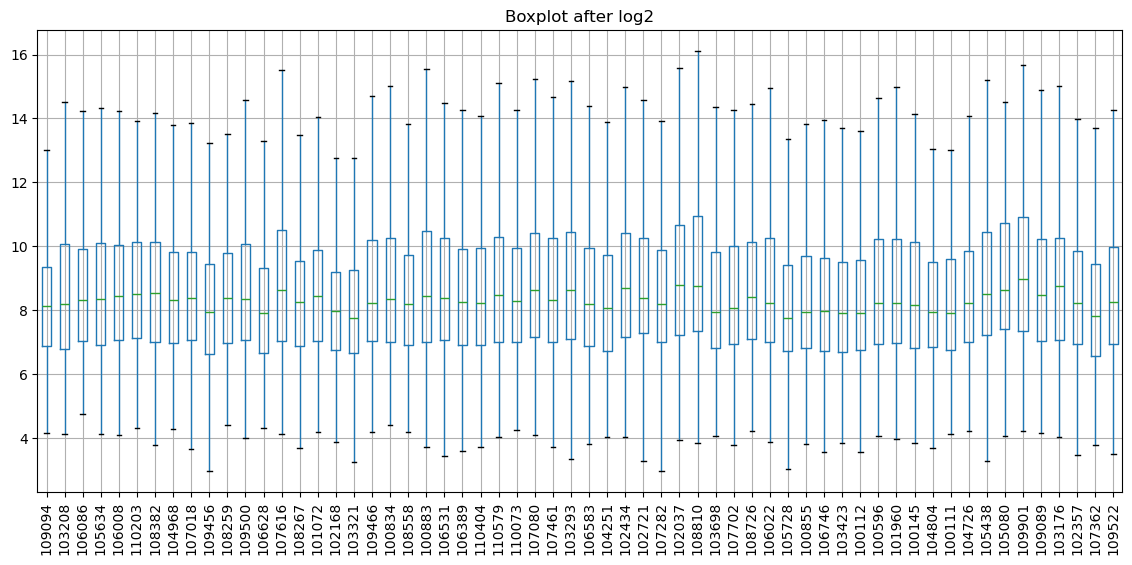

In [40]:
plt.figure(figsize=(14,6))
data_log2.T.boxplot(showfliers=False)
plt.xticks(rotation=90)
plt.title("Boxplot after log2")
plt.savefig('Boxplot_after_log2_Coimbra.png')
plt.show()

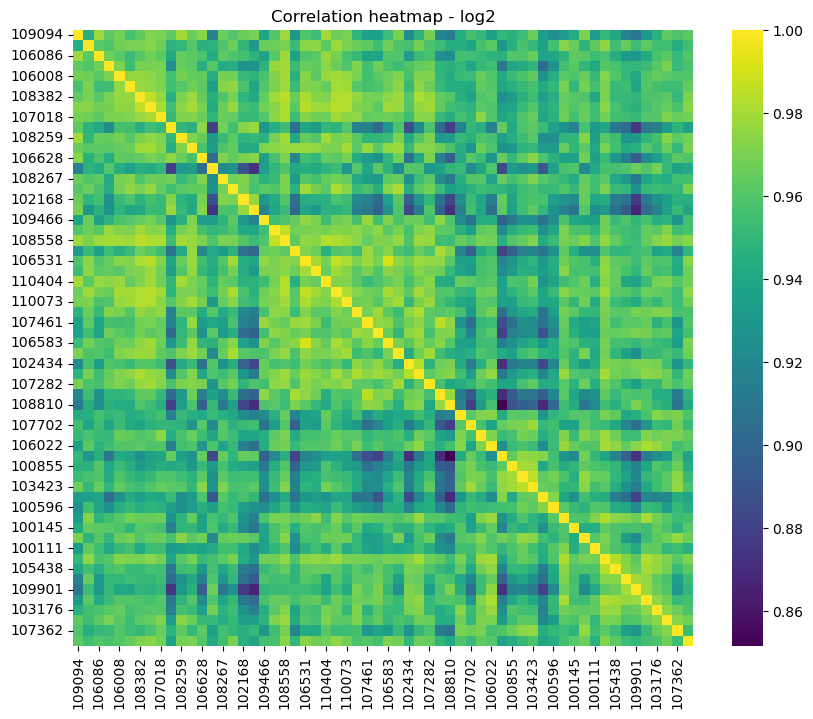

In [41]:
corr_matrix = data_log2.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="viridis")
plt.title("Correlation heatmap - log2")
#plt.savefig('Correlation heatmap - log2')
plt.show()

In [42]:
z_score_df = (data_log2-data_log2.mean())/data_log2.std()

In [43]:
z_score_df.isna().sum().sum()

0

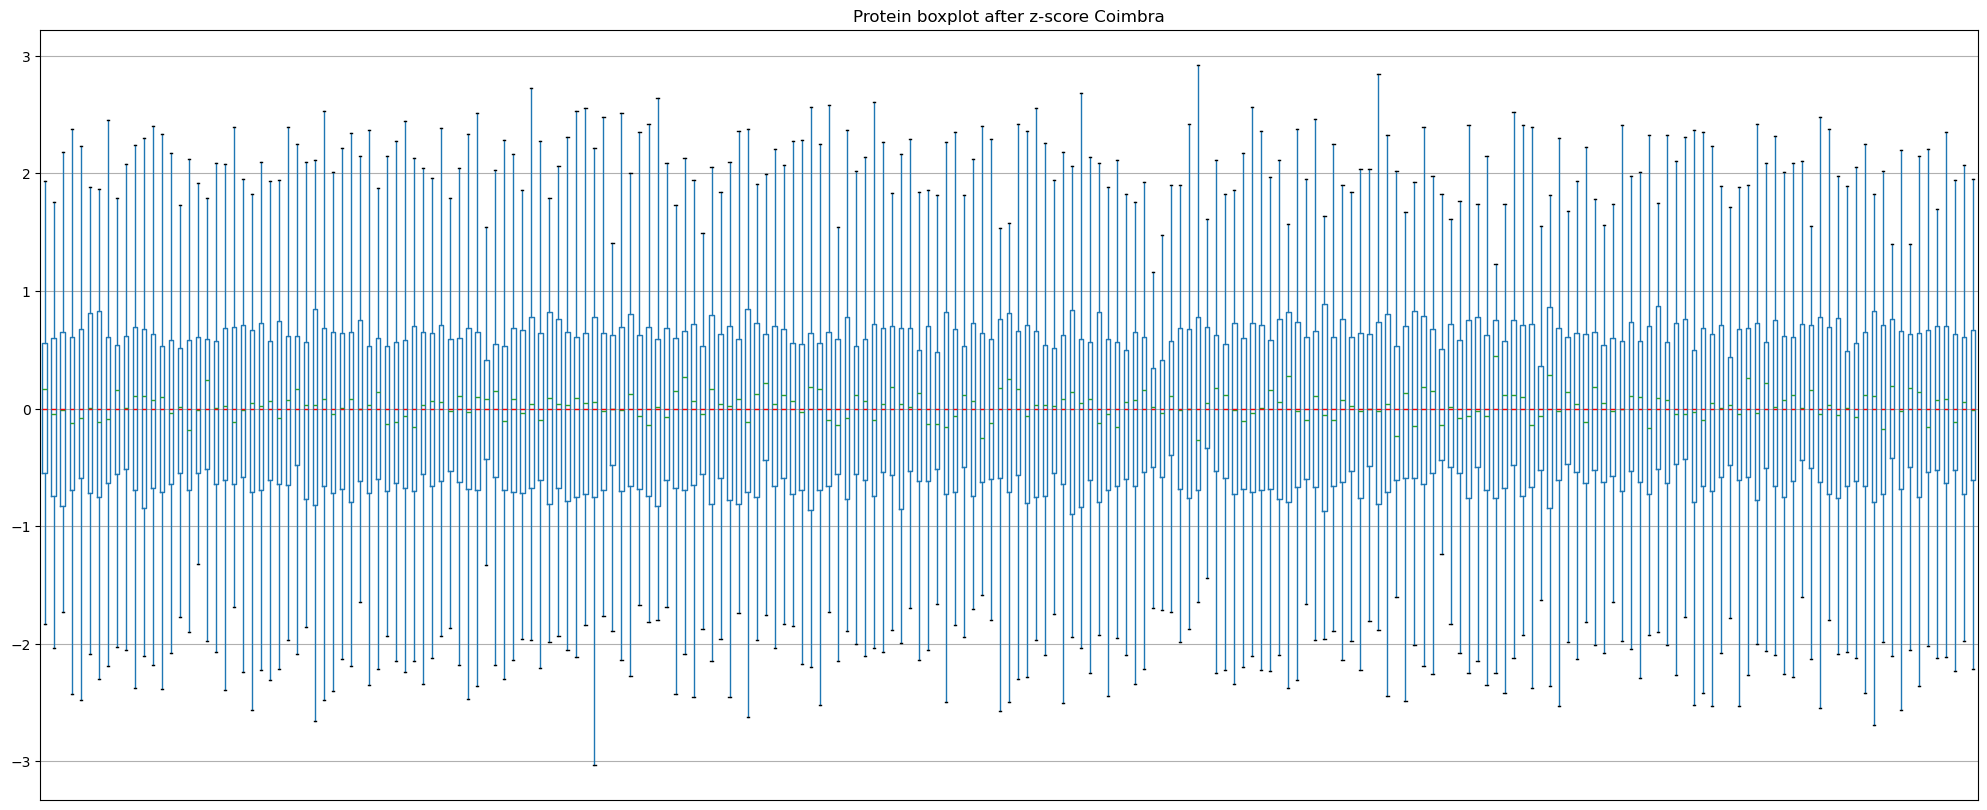

In [44]:
plt.figure(figsize=(25,10))
z_score_df.boxplot(showfliers=False, showmeans=True, meanline=True,meanprops={
        'color': 'red',         
        'linewidth': 1,         
        'linestyle': '--'      
    },)
plt.xticks([])   
plt.title("Protein boxplot after z-score Coimbra")
plt.savefig('Protein_boxplot_after_z-score_Coimbra.png')
plt.show()

In [45]:
z_score_df

Protein.Group,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X8,A0A0B4J1Y9,A0A0B4J2B5,...,Q9P2S2,Q9UBP4,Q9UKI9;P09086;P14859,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7,cRAP-P00760,cRAP-P0AEY0,cRAP-P42212
109094,-0.299893,0.345566,-0.087910,-0.312482,-0.595331,-1.071492,-0.196324,-0.197947,-0.011467,-0.977996,...,0.986824,-0.408365,-0.655430,0.325023,-0.015565,-0.483764,-0.688214,-1.212968,-0.548036,-0.313309
103208,-0.535514,-0.910779,-0.246359,-1.032784,-0.608670,0.055998,-1.044358,-0.708080,-0.491714,-0.380584,...,0.843467,-0.319179,0.425761,-0.442889,-0.305581,0.452588,-0.510709,-0.972574,-0.413666,-0.428133
106086,0.038185,0.260449,0.149848,-0.437565,-0.281140,-0.312382,-0.536795,-0.181017,0.508827,-0.198876,...,0.916983,0.597227,0.092491,1.569856,1.500261,1.116391,0.172243,-0.449715,-0.801974,-0.784406
105634,0.895233,1.608128,1.485064,0.829300,1.139552,0.873338,-1.150707,0.586510,0.427814,0.995364,...,-0.011129,0.884553,0.591762,-1.890922,-0.701803,-0.170971,-1.013830,-0.754544,-1.972970,-1.865125
106008,-0.269017,-0.343549,0.653318,0.082518,-0.055101,-1.197736,0.491791,0.439861,0.231992,-0.062760,...,-1.678280,1.272047,0.491187,0.638915,-0.476867,-0.156466,0.418209,0.346361,-0.955378,-0.817973
110203,-0.851865,-0.744116,-1.022088,-0.671964,-0.434471,-0.392974,0.898512,-0.503763,-0.699817,-1.031372,...,1.403590,1.393161,-0.274449,1.062411,0.899291,-0.361245,-0.608518,1.176008,0.645738,0.910606
108382,0.208014,0.595812,0.220086,-0.248133,-0.697164,-0.052628,1.157841,-0.577638,0.201827,-0.453583,...,0.589557,0.321945,0.205530,-0.618257,-0.505926,0.543155,0.953425,-0.518141,-0.976973,-0.524218
104968,-0.301122,0.336795,-0.012015,-0.150620,-0.904890,-0.239330,0.515941,0.228124,-0.708437,-0.204357,...,0.206593,-0.238670,-0.333927,0.259194,-0.162707,1.073316,1.403900,-0.028957,0.042310,-0.038727
107018,-0.750813,0.613114,0.190854,-0.563547,-0.405828,-0.047851,0.792658,0.301843,0.446305,0.164309,...,0.892030,-0.716483,0.480674,0.099518,0.193651,-1.407651,-1.472103,-0.262088,0.701623,0.682029
109456,-1.754784,-2.038935,-1.513407,-1.424724,-1.442594,-2.084703,-2.296572,-1.269634,-1.781388,-1.573294,...,0.238406,0.566290,-0.638345,0.980676,0.656455,-0.169899,-1.719303,-0.344193,0.427707,0.529303


In [46]:
df_MCI = pd.read_excel('sample_information.xlsx', header=1, usecols="C:F")

In [47]:
df_all_data = data_log2.merge(df_MCI, left_index=True, right_on='Sample code', how='left')

In [48]:
df_all_data

,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X8,A0A0B4J1Y9,A0A0B4J2B5,...,Q9Y4C0,Q9Y646,Q9Y6R7,cRAP-P00760,cRAP-P0AEY0,cRAP-P42212,Sample code,Groups,Age,Gender
74,10.707256,5.411257,10.023893,7.638458,9.985671,5.338670,7.244240,9.311739,9.095131,10.772999,...,7.458193,6.139852,6.967906,16.484214,16.114483,16.998469,109094,MCI-CT,42,F
75,10.510289,4.121894,9.891121,6.968736,9.974615,6.571228,6.063140,8.986320,8.741339,11.256226,...,7.385923,6.398954,7.078834,16.594989,16.185402,16.939017,103208,MCI-CT,47,F
76,10.989870,5.323903,10.223121,7.522158,10.246075,6.168520,6.770049,9.322539,9.478424,11.403204,...,7.835930,6.582637,7.505629,16.835927,15.980456,16.754548,106086,MCI-CT,48,F
77,11.706315,6.707000,11.341958,8.700062,11.423557,7.464734,5.915024,9.812152,9.418742,12.369186,...,7.287186,6.226406,6.764420,16.695459,15.362416,16.194982,105634,MCI-CT,49,F
78,10.733066,4.704031,10.645001,8.005720,10.433419,5.200661,8.202614,9.718603,9.274483,11.513303,...,7.343239,6.230420,7.659339,17.202765,15.899491,16.737168,106008,MCI-CT,50,F
79,10.245838,4.292936,9.241104,7.304219,10.118993,6.080417,8.769074,9.116656,8.588032,10.729825,...,7.686171,6.173755,7.017710,17.585073,16.744545,17.632179,110203,MCI-CT,54,F
80,11.131838,5.668079,10.281976,7.698288,9.901271,6.452478,9.130254,9.069530,9.252261,11.197180,...,7.335998,6.424015,7.993810,16.804396,15.888094,16.889266,108382,MCI-CT,55,F
81,10.706228,5.402255,10.087489,7.788953,9.729106,6.248379,8.236249,9.583534,8.581683,11.398770,...,7.421526,6.570718,8.275324,17.029816,16.426062,17.140640,104968,MCI-CT,58,F
82,10.330312,5.685836,10.257482,7.405022,10.142733,6.457701,8.621645,9.630560,9.432364,11.696972,...,7.510329,5.884200,6.478033,16.922387,16.774041,17.513828,107018,MCI-CT,59,F
83,9.491047,2.964088,8.829406,6.604319,9.283452,4.231041,4.319119,8.628099,7.791254,10.291482,...,7.625658,6.226703,6.323552,16.884552,16.629470,17.434750,109456,MCI-CT,59,F


In [49]:
df_all_data['Groups'].unique()

array(['MCI-CT', 'MCI-AD'], dtype=object)

In [50]:
df_all_data['Gender'].unique()

array(['F', 'M'], dtype=object)

In [51]:
df_ad_ct = df_all_data[(df_all_data['Groups']=='MCI-AD') | (df_all_data['Groups']=='MCI-CT')]

In [52]:
ad = df_ad_ct[df_ad_ct['Groups']=='MCI-AD']
ad_prot = ad.drop(columns=['Groups'])
ad_prot = ad_prot.drop(columns=['Gender'])
ad_prot = ad_prot.drop(columns=['Age'])
ad_prot = ad_prot.drop(columns=['Sample code'])

In [53]:
ct = df_ad_ct[df_ad_ct['Groups']=='MCI-CT']
ct_prot = ct.drop(columns=['Groups'])
ct_prot = ct_prot.drop(columns=['Gender'])
ct_prot = ct_prot.drop(columns=['Age'])
ct_prot = ct_prot.drop(columns=['Sample code'])

In [54]:
log2fc = ad_prot.mean() - ct_prot.mean()

In [55]:
from scipy.stats import ttest_ind
p_values = []

for protein in ad_prot.columns:
    stat, p = ttest_ind(ad_prot[protein], ct_prot[protein], nan_policy="omit")
    p_values.append(p)

p_values = pd.Series(p_values, index=ad_prot.columns)

In [56]:
results = pd.DataFrame({
    "log2FC": log2fc,
    "pvalue": p_values
})

results["neg_log10_p"] = -np.log10(results["pvalue"])
import numpy as np

results["color"] = "grey"

results.loc[(results["pvalue"] < 0.05) & (results["log2FC"] > 0), "color"] = "red"
results.loc[(results["pvalue"] < 0.05) & (results["log2FC"] < 0), "color"] = "blue"

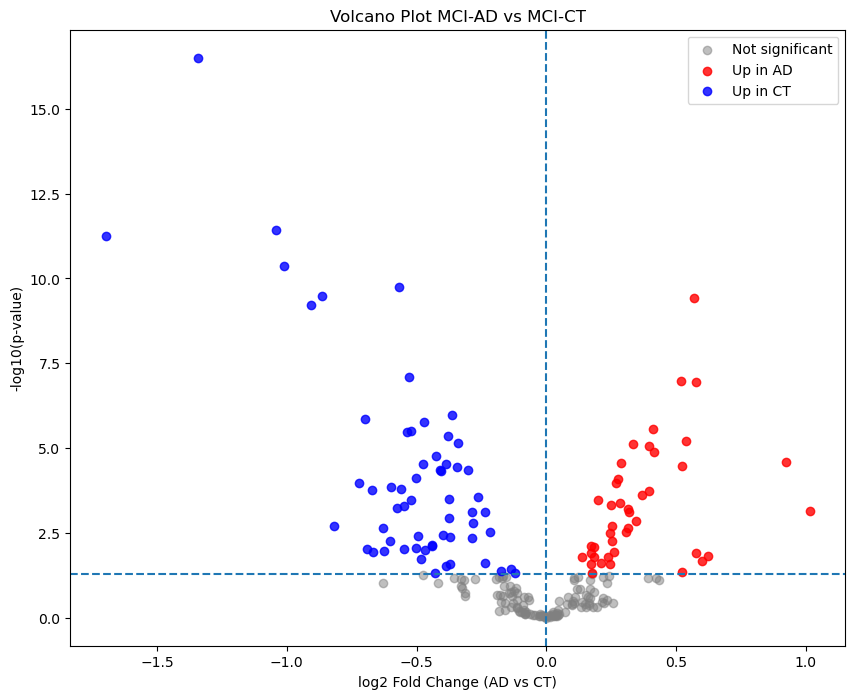

In [57]:
plt.figure(figsize=(10,8))

# non significative
plt.scatter(
    results.loc[results["color"] == "grey", "log2FC"],
    results.loc[results["color"] == "grey", "neg_log10_p"],
    color="grey",
    alpha=0.5,
    label="Not significant"
)

# up in AD
plt.scatter(
    results.loc[results["color"] == "red", "log2FC"],
    results.loc[results["color"] == "red", "neg_log10_p"],
    color="red",
    alpha=0.8,
    label="Up in AD"
)

# up in CT
plt.scatter(
    results.loc[results["color"] == "blue", "log2FC"],
    results.loc[results["color"] == "blue", "neg_log10_p"],
    color="blue",
    alpha=0.8,
    label="Up in CT"
)

plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("log2 Fold Change (AD vs CT)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot MCI-AD vs MCI-CT")
plt.savefig('Volcano_Plot_MCI-AD_vs_MCI-CT_Coimbra.png')
plt.legend()
plt.show()

In [58]:
from statsmodels.stats.multitest import multipletests

results["FDR"] = multipletests(results["pvalue"], method="fdr_bh")[1]

In [59]:
significant = results[(results["FDR"] < 0.05)]
print(len(significant))

89


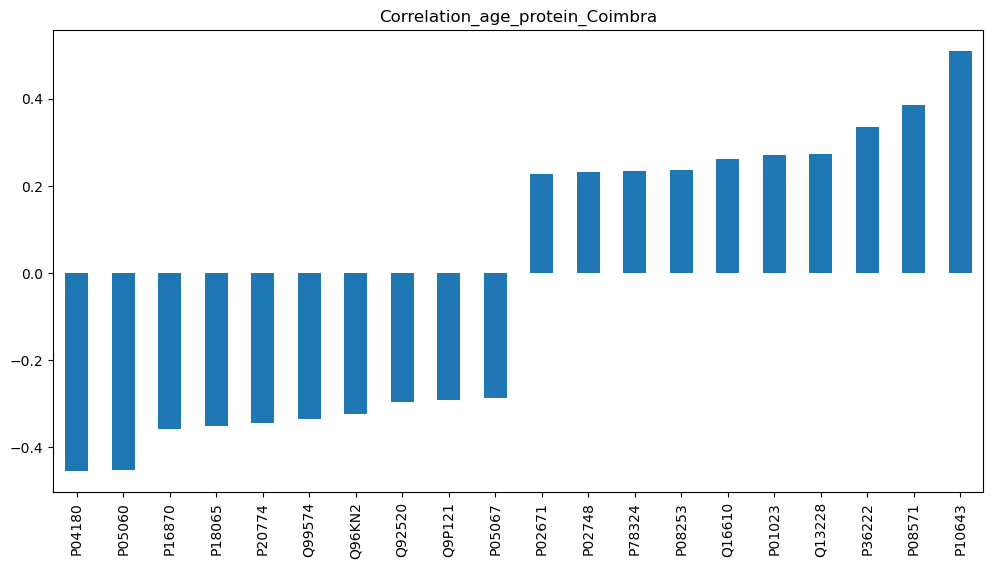

In [60]:
import matplotlib.pyplot as plt

proteins = df_all_data.iloc[:, :-4]  # colonne proteine
age = df_all_data["Age"]

correlations = proteins.apply(lambda x: x.corr(df_all_data["Age"]))
corr_sorted = correlations.sort_values()

top_neg = corr_sorted.head(10)
top_pos = corr_sorted.tail(10)

top = pd.concat([top_neg, top_pos])

top.plot(kind="bar", figsize=(12,6))
plt.title("Correlation_age_protein_Coimbra")
plt.savefig('Correlation_age_protein_Coimbra.png')

<Figure size 800x600 with 0 Axes>

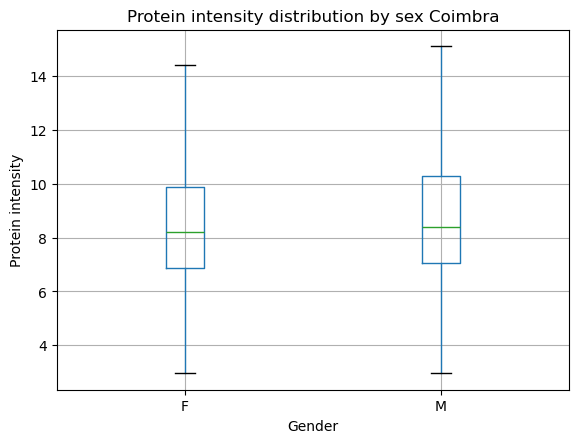

In [61]:
proteins = df_all_data.iloc[:, :-4]

df_long = proteins.copy()
df_long["Gender"] = df_all_data["Gender"]

df_long = df_long.melt(id_vars="Gender",
                       var_name="Protein",
                       value_name="Intensity")

plt.figure(figsize=(8,6))

df_long.boxplot(column="Intensity", by="Gender", showfliers=False)

plt.title("Protein intensity distribution by sex Coimbra")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Protein intensity")
plt.savefig('Protein_intensity_distribution_by_sex_Coimbra.png')
plt.show()

In [62]:
list_groups = df_all_data['Groups'].tolist()
import pickle
with open('list_groups_Coimbra_2.pkl', 'wb') as f:
    pickle.dump(list_groups, f)
data_log2.to_pickle('data_log2_Coimbra.pkl')

/tmp/ipykernel_28952/705472631.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


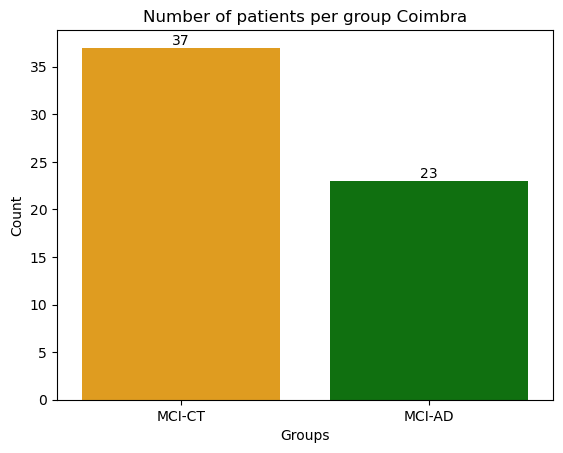

In [64]:
ax = sns.countplot(
    data=df_all_data,
    x='Groups',
    palette={'MCI-AD': 'green', 'MCI-CT': 'orange'}
)

# aggiungi numeri
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title('Number of patients per group Coimbra')
plt.ylabel('Count')
plt.savefig('Number_of_patient_per_group_Coimbra')
plt.show()